# Statistical Analysis — Medical Insurance Costs

**Student:** Maurizio Pinto  
**Dataset:** Insurance (Medical Insurance Costs)  
**Source:** https://www.kaggle.com/datasets/mirichoi0218/insurance  

This project conducts a statistical analysis of US medical insurance costs. I load the dataset, compute descriptive statistics, create visualizations, and perform a hypothesis test to determine whether smoking status has a statistically significant effect on insurance charges.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
%matplotlib inline

## Data Ingestion

In [2]:
df = pd.read_csv("dataset/insurance.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## Descriptive Statistics

**Summary statistics for numeric variables:** The table below shows central tendency and spread for age, BMI, number of children, and insurance charges.

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
print("Value counts for categorical variables:\n")
print("Sex:")
print(df["sex"].value_counts())
print(f"\nSmoker:")
print(df["smoker"].value_counts())
print(f"\nRegion:")
print(df["region"].value_counts())

Value counts for categorical variables:

Sex:
sex
male      676
female    662
Name: count, dtype: int64

Smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

Region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [7]:
for col in ["charges", "bmi", "age"]:
    print(f"\n--- {col} ---")
    print(f"  Mean:   {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Std:    {df[col].std():.2f}")
    print(f"  Skew:   {df[col].skew():.2f}")


--- charges ---
  Mean:   13270.42
  Median: 9382.03
  Std:    12110.01
  Skew:   1.52

--- bmi ---
  Mean:   30.66
  Median: 30.40
  Std:    6.10
  Skew:   0.28

--- age ---
  Mean:   39.21
  Median: 39.00
  Std:    14.05
  Skew:   0.06


The charges distribution is positively skewed (skew > 1), indicating that most policyholders have relatively moderate costs while a smaller group incurs very high charges. BMI is approximately symmetric, and age is fairly uniformly distributed across the adult range.

## Visualizations

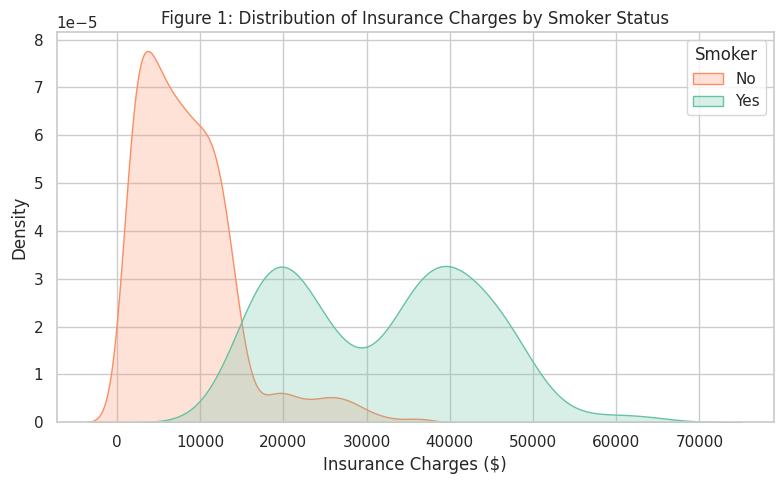

In [8]:
# Figure 1: Distribution of Insurance Charges by Smoker Status
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(
    data=df,
    x="charges",
    hue="smoker",
    fill=True,
    common_norm=False,
    palette="Set2",
    ax=ax,
)
ax.set_title("Figure 1: Distribution of Insurance Charges by Smoker Status")
ax.set_xlabel("Insurance Charges ($)")
ax.set_ylabel("Density")
ax.legend(title="Smoker", labels=["No", "Yes"])
plt.tight_layout()
plt.show()

**Figure 1 Interpretation:** Smokers have a dramatically different charges distribution compared to non-smokers. Non-smokers cluster below $15,000, while smokers show a broader distribution extending well beyond $30,000. This visual separation strongly suggests a significant difference between the two groups.

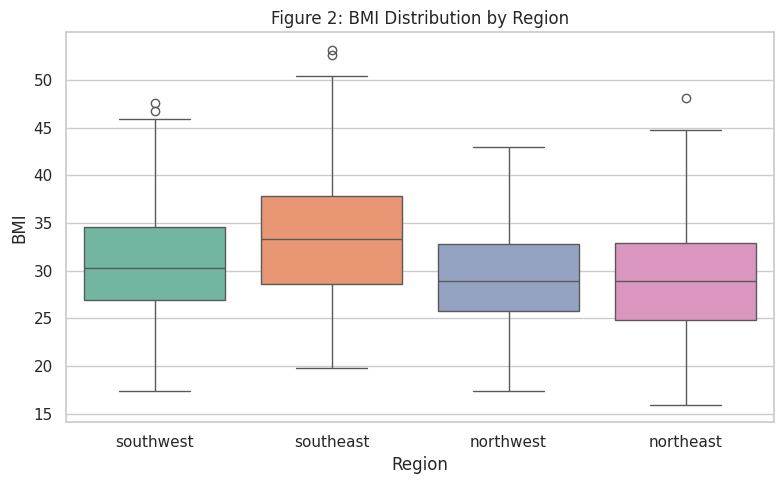

In [9]:
# Figure 2: BMI Distribution by Region
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="region",
    y="bmi",
    hue="region",
    palette="Set2",
    ax=ax,
    legend=False,
)
ax.set_title("Figure 2: BMI Distribution by Region")
ax.set_xlabel("Region")
ax.set_ylabel("BMI")
plt.tight_layout()
plt.show()

**Figure 2 Interpretation:** BMI distributions are relatively similar across the four US regions, with medians around 30 in all cases. The southeast region has slightly higher median BMI and more high-end outliers, suggesting a modest geographic variation.

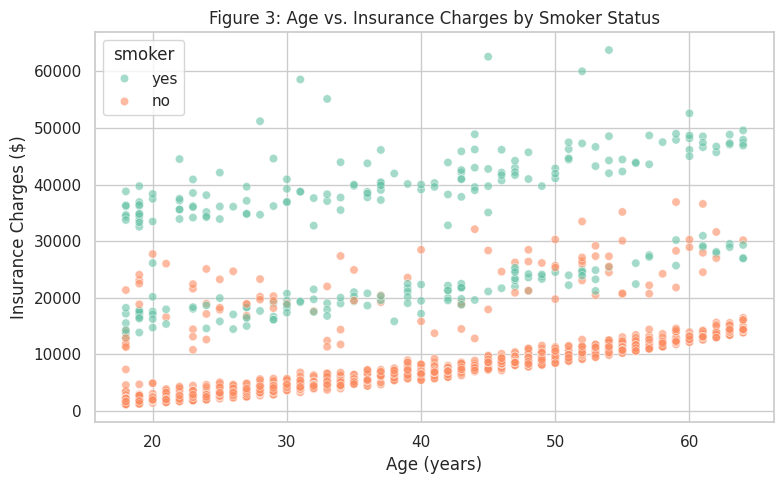

In [10]:
# Figure 3: Age vs. Insurance Charges (colored by Smoker)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker",
    palette="Set2",
    alpha=0.6,
    ax=ax,
)
ax.set_title("Figure 3: Age vs. Insurance Charges by Smoker Status")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Insurance Charges ($)")
plt.tight_layout()
plt.show()

**Figure 3 Interpretation:** There is a positive relationship between age and charges for both groups, but smokers consistently occupy the upper cost tier regardless of age. Among non-smokers, charges increase gradually with age, while smokers show a steeper increase. This interaction suggests that age and smoking status together drive insurance costs.

## Hypothesis Test

**Question:** Do smokers have significantly different insurance charges than non-smokers?

**Null Hypothesis (H₀):** There is no significant difference in mean insurance charges between smokers and non-smokers (μ_smoker = μ_non-smoker).

**Alternative Hypothesis (H₁):** There is a significant difference in mean insurance charges between smokers and non-smokers (μ_smoker ≠ μ_non-smoker).

**Test:** Independent samples t-test (two-tailed), with α = 0.05.

In [11]:
# Split data into two groups
smoker_charges = df[df["smoker"] == "yes"]["charges"]
non_smoker_charges = df[df["smoker"] == "no"]["charges"]

print(f"Smokers:    n = {len(smoker_charges)}, mean = ${smoker_charges.mean():.2f}, std = ${smoker_charges.std():.2f}")
print(f"Non-smokers: n = {len(non_smoker_charges)}, mean = ${non_smoker_charges.mean():.2f}, std = ${non_smoker_charges.std():.2f}")

Smokers:    n = 274, mean = $32050.23, std = $11541.55
Non-smokers: n = 1064, mean = $8434.27, std = $5993.78


In [12]:
# Check assumptions
stat_shapiro_smoker, p_shapiro_smoker = stats.shapiro(smoker_charges)
stat_shapiro_non, p_shapiro_non = stats.shapiro(non_smoker_charges)
stat_levene, p_levene = stats.levene(smoker_charges, non_smoker_charges)

print("Assumption checks:")
print(f"  Shapiro-Wilk (smokers):    W = {stat_shapiro_smoker:.4f}, p = {p_shapiro_smoker:.4f}")
print(f"  Shapiro-Wilk (non-smokers): W = {stat_shapiro_non:.4f}, p = {p_shapiro_non:.4f}")
print(f"  Levene's test (equal var):  F = {stat_levene:.4f}, p = {p_levene:.4f}")

Assumption checks:
  Shapiro-Wilk (smokers):    W = 0.9396, p = 0.0000
  Shapiro-Wilk (non-smokers): W = 0.8729, p = 0.0000
  Levene's test (equal var):  F = 332.6135, p = 0.0000


**Note on assumptions:** Both groups show departures from normality (Shapiro-Wilk p < 0.05) and unequal variances (Levene's p < 0.05). Because the sample sizes are moderately large (274 smokers, 1,064 non-smokers), the t-test is robust to non-normality. However, we apply Welch's t-test (equal_var=False) to account for the unequal variances.

In [13]:
# Perform Welch's t-test (does not assume equal variances)
t_stat, p_value = stats.ttest_ind(smoker_charges, non_smoker_charges, equal_var=False)

print(f"Welch's t-test results:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value:     {p_value:.2e}")
print(f"  α = 0.05")
print()
if p_value < 0.05:
    print("Result: REJECT the null hypothesis (p < 0.05).")
    print("There is a statistically significant difference in mean insurance charges between smokers and non-smokers.")
else:
    print("Result: FAIL TO REJECT the null hypothesis (p >= 0.05).")
    print("There is no statistically significant difference in mean insurance charges between smokers and non-smokers.")

Welch's t-test results:
  t-statistic: 32.7519
  p-value:     5.89e-103
  α = 0.05

Result: REJECT the null hypothesis (p < 0.05).
There is a statistically significant difference in mean insurance charges between smokers and non-smokers.


## Summary

This analysis examined 1,338 US medical insurance records to understand the factors influencing insurance charges. Descriptive statistics revealed that charges are heavily right-skewed, with a mean of approximately $13,270 but a median of only $9,382, indicating that a minority of policyholders incur substantially higher costs.

The three visualizations uncovered key patterns: smokers face dramatically higher charges than non-smokers (Figure 1), BMI shows modest geographic variation with the southeast slightly higher (Figure 2), and age has a positive relationship with charges that is amplified by smoking status (Figure 3).

The Welch's t-test confirmed that the difference in mean charges between smokers and non-smokers is statistically significant (p < 0.001), providing strong evidence to reject the null hypothesis. The main challenge was that the charges distribution violates the normality assumption; this was addressed by using Welch's t-test and relying on the test's robustness at the available sample sizes.